# Exercise: Data Exploration and Basic Visualization

## Dataset

The dataset contains information about passengers aboard the Titanic. The CSV file was obtained from [Kaggle](https://www.kaggle.com/datasets/yasserh/titanic-dataset) and includes the following columns:

| Variable | Description | Value |
|:----------|:-----------|:------------|
| PassengerId| Passenger ID |  |
| Survived | Weather survived or not | 0 = No, 1 = Yes |
| Pclass | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| Name | Name of the passenger |  |
| Sex | Gender |  |
| Age | Age in years |  |
| SibSp | Number of siblings / spouses aboard |  |
| Parch | Number of parents / children aboard |  |
| Ticket | Ticket number |  |
| Fare | Passenger fare |  |
| Cabin | Cabin number |  |
| Embarked | Port of embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |

## Load the Data

Import Pandas and read the `'titanic.csv'` file into a DataFrame, setting `PassengerId` column as the index. Then display the first few rows of the DataFrame.

In [1]:
import pandas as pd

df = pd.read_csv('data/titanic.csv', index_col='PassengerId')
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Inspect the DataFrame

- How many passengers are in the dataset? How many of them survived?


In [2]:
print("Number of passengers:", df.shape[0])
print("Number of passengers survived:", df['Survived'].sum())

Number of passengers: 891
Number of passengers survived: 342


- Which columns contain missing values, and how many are missing in each?
- What might this reveal about data collection in this dataset?

In [3]:
df.count()

Survived    891
Pclass      891
Name        891
Sex         891
Age         714
SibSp       891
Parch       891
Ticket      891
Fare        891
Cabin       204
Embarked    889
dtype: int64

In [4]:
df.shape[0] - df.count()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [5]:
df.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

> `Age` (177 missing), `Cabin` (687 missing), `Embarked` (2 missing)
> 
>  Missing values indicate incomplete records in these fields.

- What are the data types of each column? Which columns are numeric, and which are categorical?

In [6]:
df.dtypes

Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Cabin        object
Embarked     object
dtype: object

> **Numeric columns**: Survived, Pclass, Age, SibSp, Parch, Fare
>
> **Categorical/`object` columns**: Name, Sex, Ticket, Cabin, Embarked


## Summary Statistics

- Calculate the minimum, maximum, mean, and standard deviation for all numeric columns.
- Which variable exhibits the greatest variability?

In [7]:
stats_df = pd.DataFrame({
    'min': df.min(numeric_only=True),
    'max': df.max(numeric_only=True),
    'mean': df.mean(numeric_only=True),
    'std': df.std(numeric_only=True)
})
stats_df

,min,max,mean,std
Survived,0.00,1.0000,0.383838,0.486592
Pclass,1.00,3.0000,2.308642,0.836071
Age,0.42,80.0000,29.699118,14.526497
SibSp,0.00,8.0000,0.523008,1.102743
Parch,0.00,6.0000,0.381594,0.806057
Fare,0.00,512.3292,32.204208,49.693429


> The `Fare` values shows the largest variance.

- Use `.value_counts()` to determine:

  - Which passenger class is most common?
  - Which embarkation port has the highest passenger count?

In [8]:
# idxmax() returns the index (label) of the maximum value along a given axis

print("Most common passenger class:", df['Pclass'].value_counts().idxmax())
df['Pclass'].value_counts()

Most common passenger class: 3


Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [9]:
# value_counts() returns a Series with counts sorted in descending order by default.
# So, the index of the first value has the highest count.

print("Embarkation port with highest passenger count:", df['Embarked'].value_counts().index[0])
df['Embarked'].value_counts()

Embarkation port with highest passenger count: S


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

> The 3rd passenger class is most common
> 
> Southampton (S) has the highest passenger count.

## Survival Analysis

- Identify the 10 youngest passengers who survived using method chaining.
   - *Note*: We haven't covered Boolean indexing yet. The expression `df[df['Survived'] == 1]` returns only the records for passengers who survived.
- What patterns do you observe that might help explaining their survival? (E.g., age, passenger class, etc.)

In [10]:
top_10_young_survied = df[df['Survived']==1].sort_values('Age').head(10)
top_10_young_survied

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,NaN,S
79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S
306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S
382,1,3,"Nakid, Miss. Maria (""Mary"")",female,1.00,0,2,2653,15.7417,NaN,C
828,1,2,"Mallet, Master. Andre",male,1.00,0,2,S.C./PARIS 2079,37.0042,NaN,C


> (*Sample Answer*) The 10 youngest survivors are infants under 1 year old, primarily from second and third passenger class, with none embarking from Queenstown (Q). Their survival seems to align with the "women and children first" protocol, aided by accompanying parents who secured lifeboat spots.
>
> All were children prioritized under lifeboat loading rules, with 100% infants. Proximity to parents and small size might have eased boarding in chaotic evacuations.

- Identify the top 10 oldest passengers who perished, and note any observed patterns.

In [11]:
oldest_not_survived = df[df['Survived']==0].sort_values('Age', ascending=False).head(10)
oldest_not_survived

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S
494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
281,0,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,NaN,Q
457,0,1,"Millet, Mr. Francis Davis",male,65.0,0,0,13509,26.5500,E38,S


> (*Sample Answer*) Older adults aged 65–75 formed the top 10 oldest non-survivors, majority from 1st and 3rd passenger classes (half in 1st class) and all male. Most traveled without siblings, spouses, parents, or children aboard, heightening their vulnerability during evacuation.
>
> Predominantly solitary male travelers lacked family ties that sometimes aided access to lifeboats. Half hailed from affluent 1st class, yet class offered no survival guarantee for elderly men.
>
> All-male composition seems to align with "women and children first" protocol, sidelining older men regardless of status. Solo status (few family onboard) reduced boarding priority compared to grouped survivors. Age-related mobility likely compounded risks in chaos.

- Sort the data by passenger fare. Are there any passengers who paid a fare of 0? If so, how many? 
- List and examine their records. Do you notice anything unexpected?

In [12]:
sorted_by_fare = df.sort_values(by='Fare')
num_0_paid = sorted_by_fare[sorted_by_fare['Fare']==0].shape[0]

print("Number of passengers who paid 0 fare:", num_0_paid)

sorted_by_fare.head(num_0_paid)

Number of passengers who paid 0 fare: 15


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S
598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S
303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S
634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0,NaN,S
278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,NaN,S
414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0,NaN,S
675,0,2,"Watson, Mr. Ennis Hastings",male,NaN,0,0,239856,0.0,NaN,S
264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S
467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0,NaN,S


> (*Sample Answer*) Some passengers paid a fare of 0, which may indicate crew members or special cases such as individuals granted complimentary passage (e.g., staff or service-related travelers). All zero-fare passengers were male, and only one survived — consistent with historically low crew survival rates and the prioritization of passengers during evacuation.
>
> All zero-fare passengers embarked from Southampton, the primary port for crew boarding. None had recorded siblings/spouses or parents/children aboard, suggesting solo travel patterns typical of onboard personnel.

- Sort the data by index and display the first 10 entries. How does this ordering differ from sorting by `Fare` or `Age`?

In [13]:
sorted_by_index = df.sort_index()
sorted_by_index.head(10)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S


> Sorting by index returns the dataset to its original order, based on `PassengerId`.

## Basic Visualization

- Create a histogram of passenger ages using 30 bins. Do you notice any clusters or patterns in specific age ranges?

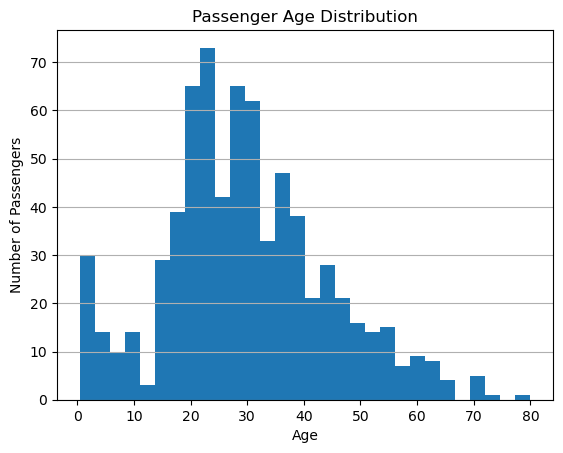

In [14]:
ax = df['Age'].plot(kind='hist', bins=30)
ax.set_title('Passenger Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Number of Passengers')
ax.grid(axis='y')

> Passenger ages are clustered between 15 and 40 years, with a noticeable group of children under 10.

- Create a bar chart showing the number of passengers in each passenger class. Which class has the most passengers?

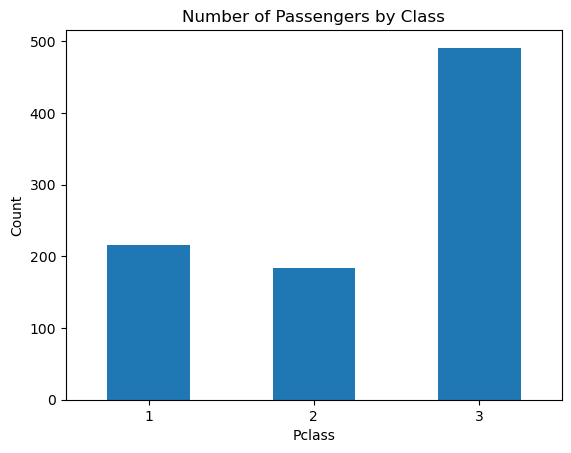

In [15]:
# ax = df['Pclass'].value_counts().plot(kind='bar', rot=0)
ax = df['Pclass'].value_counts().sort_index().plot(kind='bar', rot=0)
ax.set_title('Number of Passengers by Class')
ax.set_xlabel('Pclass')
ax.set_ylabel('Count');

> The majority of passengers were in third class, followed by first class, and then second class.

- Create a scatter plot of `Age` (x-axis) vs `Fare` (y-axis). What patterns do you observe? For example, do older passengers tend to pay higher fares? Do young children generally have lower fares?
  - Color the points by passenger class (`Pclass`) using the `c` parameter and set `alpha=0.5` for transparency.
  - Set y-axis limit to [0, 100].

(0.0, 100.0)

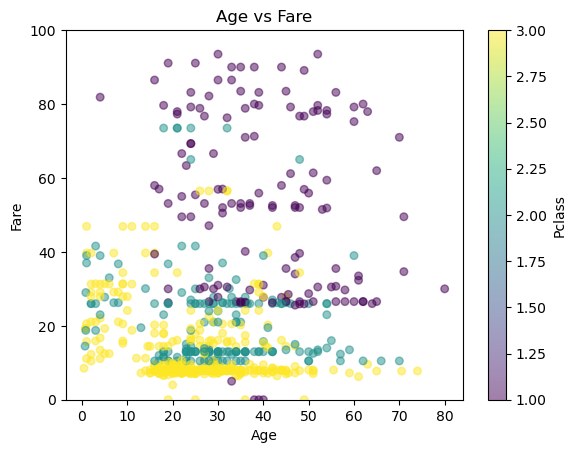

In [16]:
ax = df.plot(kind='scatter', x='Age', y='Fare', c='Pclass', cmap='viridis', s=30, alpha=0.5)
ax.set_title('Age vs Fare')
ax.set_xlabel('Age')
ax.set_ylabel('Fare')
ax.set_ylim(0, 100)

> Most young children paid relatively low fares, while older adults are distributed across a wide range of fares, showing greater variation in ticket prices.

- Compare the average age of survivors versus non-survivors using `mean()`. Based on the results, does age appear to have influenced survival?

In [17]:
avg_age_survived = df.loc[df['Survived']==1, 'Age']
avg_age_not_survived = df.loc[df['Survived']==0, 'Age']

print("Average age of survivors:", avg_age_survived.mean())
print("Average age of non-survivors:", avg_age_not_survived.mean())

Average age of survivors: 28.343689655172415
Average age of non-survivors: 30.62617924528302


> The average ages of survivors and non-survivors differ by approximately 2.3 years, suggesting that age does not appear to have had a strong influence on survival.

- Create overlaid histograms of ages for survivors and non-survivors on a single plot for direct comparison. Do the age distributions suggest survival was age-related?
  - Use `alpha=0.5` for transparency to reveal overlapping regions.
  - Set `label="Survived"` and `label="Not Survived"` for the respective histograms.

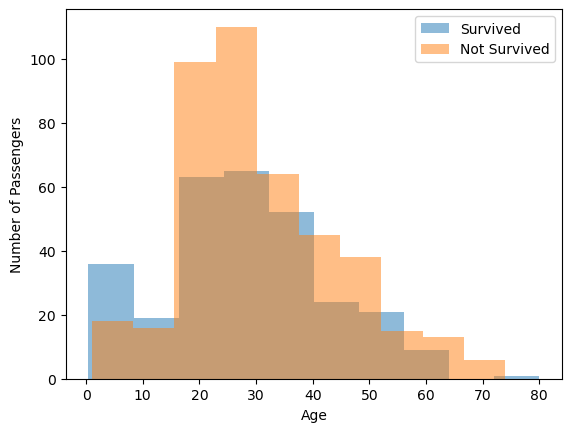

In [18]:
ax = avg_age_survived.plot(kind='hist', alpha=0.5, label='Survived')
avg_age_not_survived.plot(kind='hist', alpha=0.5, label='Not Survived')

ax.set_ylabel('Number of Passengers')
ax.set_xlabel('Age')
ax.legend();

> (*Sample Answer*) The distributions largely overlap. However, children under 10 appear more likely to survive, whereas adults aged 20–30, 40–50, and over 65 show a higher likelihood of not surviving.
>
> (*Note: These observations may change if a different number of bins is used.*)